In [30]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Path to src_Jeffery.py
src_path = Path("../Pysimulations").resolve()

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

import src_Jeffery as jf

import tomli
from pathlib import Path

parameter_file = Path("parameters.toml")

with open(parameter_file, "rb") as f:
    params = tomli.load(f)

# PARTICLE PARAMETERS

Length = params["particle"]["length"]
diameter = params["particle"]["diameter"]

swimming_speed = params["particle"]["swimming_speed"]

eta = params["particle"]["eta"]

n_particle = params["particle"]["n_particle"]
n_medium = params["particle"]["n_medium"]


# INITIAL CONDITIONS

R0 = np.array([
    params["initial"]["x0"],
    params["initial"]["y0"],
    params["initial"]["z0"]
], dtype=float)

theta0_deg = params["initial"]["theta0_deg"]
phi0_deg = params["initial"]["phi0_deg"]


# FLOW PARAMETERS

gamma = params["flow"]["gamma"]
plane = params["flow"]["plane"]


# OPTICAL PARAMETERS

wavelength = params["optics"]["wavelength"]
w0 = params["optics"]["w0"]
laser_power = params["optics"]["laser_power"]

beam_axis = np.array(
    params["optics"]["beam_axis"],
    dtype=float
)

e_pol = np.array(
    params["optics"]["polarization"],
    dtype=float
)


# SIMULATION PARAMETERS

t0 = params["simulation"]["t0"]
tf = params["simulation"]["tf"]
n_points = params["simulation"]["n_points"]
rtol = params["simulation"]["rtol"]
atol = params["simulation"]["atol"]



print("PARTICLE")
print("Length =", Length, "m")
print("diameter =", diameter, "m")
print("swimming_speed =", swimming_speed, "m/s")
print("eta =", eta, "Pa s")
print("n_particle =", n_particle)
print("n_medium =", n_medium)

print()

print("INITIAL CONDITIONS")
print("R0 =", R0, "m")
print("theta0 =", theta0_deg, "deg")
print("phi0 =", phi0_deg, "deg")

print()

print("FLOW")
print("gamma =", gamma, "1/s")
print("plane =", plane)

print()

print("OPTICS")
print("wavelength =", wavelength, "m")
print("w0 =", w0, "m")
print("laser_power =", laser_power, "W")
print("beam_axis =", beam_axis)
print("polarization =", e_pol)



print()

print("SIMULATION")
print("t0 =", t0, "s")
print("tf =", tf, "s")
print("n_points =", n_points)

PARTICLE
Length = 5e-07 m
diameter = 7e-08 m
swimming_speed = 1e-05 m/s
eta = 0.000953 Pa s
n_particle = 1.38
n_medium = 1.33

INITIAL CONDITIONS
R0 = [0. 0. 0.] m
theta0 = 25.0 deg
phi0 = 25.0 deg

FLOW
gamma = 1 1/s
plane = xz

OPTICS
wavelength = 1.064e-06 m
w0 = 1.9e-06 m
laser_power = 0.025 W
beam_axis = [0. 0. 1.]
polarization = [0. 1. 0.]

SIMULATION
t0 = 0.0 s
tf = 300.0 s
n_points = 4000


In [31]:
#Particle Geometry
aspect_ratio = Length/diameter

beta = jf.lambda_ar(aspect_ratio)
print("Bretherton parameter: ",beta)
print("With aspecto ratio of: ",aspect_ratio)

a = Length/2
b = diameter/2

Volume = (4/3)*np.pi*a*(b**2)
print("the volume is:", Volume, "m^3")

alpha_scalar = jf.alpha(Volume, n_particle, n_medium)
print("The particle's polarizability is:", alpha_scalar)
#angle to radians 
theta0 = np.deg2rad(theta0_deg)
phi0 = np.deg2rad(phi0_deg)

p0 = jf.sph_to_vec(theta0, phi0)
print("the initial orientation is p: ", p0)
print("||p0|| =", np.linalg.norm(p0))

Bretherton parameter:  0.9615535504119262
With aspecto ratio of:  7.142857142857142
the volume is: 1.2828170002158323e-21 m^3
The particle's polarizability is: 8.483977117647845e-34
the initial orientation is p:  [0.38302222 0.1786062  0.90630779]
||p0|| = 1.0


In [32]:
#Background flow

G = jf.grad_u_simple_shear(gamma,plane)

E, W = jf.decompose_grad_u(G)

print("Velocity gradient G:")
print(G)

print("\nRate-of-strain tensor E:")
print(E)

print("\nRotation tensor W:")
print(W)

Velocity gradient G:
[[0. 0. 1.]
 [0. 0. 0.]
 [0. 0. 0.]]

Rate-of-strain tensor E:
[[0.  0.  0.5]
 [0.  0.  0. ]
 [0.5 0.  0. ]]

Rotation tensor W:
[[ 0.   0.   0.5]
 [ 0.   0.   0. ]
 [-0.5  0.   0. ]]


In [33]:
#Jeffery eq
p_dot_0 = jf.jeffery_rhs_vector(t0,p0,E,W,beta)
print("p0 =", p0)
print("p_dot(0) =", p_dot_0)
print("||p_dot(0)|| =", np.linalg.norm(p_dot_0))

t_eval = np.linspace(t0,tf,n_points)

sol_jeffery = solve_ivp(
    fun=lambda t, p: jf.jeffery_rhs_vector(t,p,E,W,beta),
    t_span=(t0, tf),
    y0=p0,
    t_eval=t_eval,
    rtol=rtol,
    atol=atol
)

P_raw = sol_jeffery.y.T

norm_raw = np.linalg.norm(P_raw,axis=1)

P = jf.normalize_rows(P_raw)
p0_sim = P[0]
pf = P[-1]

px = P[:, 0]
py = P[:, 1]
pz = P[:, 2]

print("Initial director =", p0_sim)
print("Final director =", pf)

print(
    "Maximum norm error =",
    np.max(np.abs(norm_raw - 1.0))
)
theta, phitan, phi = jf.directors_to_angles(P)

theta_deg = np.rad2deg(theta)
phi_deg = np.rad2deg(phi)

p0 = [0.38302222 0.1786062  0.90630779]
p_dot(0) = [ 0.76103669 -0.05961694 -0.30987928]
||p_dot(0)|| = 0.823866611340437
Initial director = [0.38302222 0.1786062  0.90630779]
Final director = [-0.9500432   0.06548931 -0.30517054]
Maximum norm error = 4.6707227863151957e-08


In [34]:
# ============================================================
# OPTICAL AND MOBILITY PARAMETERS
# ============================================================

zR = jf.rayleigh_range(
    w0=w0,
    lam=wavelength
)

U0 = jf.trap_depth(
    alpha=alpha_scalar,
    P=laser_power,
    w0=w0
)

alpha_v = alpha_scalar / Volume

effective_radius = diameter / 2.0

translational_mobility = 1.0 / (
    6.0 * np.pi * eta * effective_radius
)

rotational_drag = jf.rotational_drag_sphere(
    eta=eta,
    effective_radius=effective_radius
)

gradient_perpendicular_axis = np.array(
    [1.0, 0.0, 0.0],
    dtype=float
)

print("zR =", zR, "m")
print("U0 =", U0, "J")
print("alpha_v =", alpha_v)
print("translational mobility =", translational_mobility, "m/(N s)")
print("rotational drag =", rotational_drag, "N m s")

zR = 1.0658975074679655e-05 m
U0 = 1.4091037978393884e-21 J
alpha_v = 6.613552140500498e-13
translational mobility = 1590515595.7816954 m/(N s)
rotational drag = 1.0269206650127782e-24 N m s


In [35]:
# ============================================================
# DISCRETIZED PARTICLE VOLUME
# ============================================================

body_points = jf.prolate_spheroid_points(
    Length=Length,
    diameter=diameter,
    n_grid=13
)

print("Number of body points =", len(body_points))

Number of body points = 921


In [36]:
# ============================================================
# COUPLED ACTIVE-PARTICLE DYNAMICS
# ============================================================

def coupled_rhs(t, state):

    R = state[0:3]

    p = state[3:6]
    p = p / np.linalg.norm(p)

    # --------------------------------------------------------
    # TRANSLATION
    # --------------------------------------------------------

    u_flow = G @ R

    v_swim = swimming_speed * p

    F_opt = jf.gaussian_com_force(
        R=R,
        U0=U0,
        w0=w0,
        zR=zR
    )

    v_opt = translational_mobility * F_opt

    R_dot = (
        u_flow
        + v_swim
        + v_opt
    )

    # --------------------------------------------------------
    # JEFFERY ORIENTATION
    # --------------------------------------------------------

    p_dot_jeffery = jf.jeffery_rhs_vector(
        t,
        p,
        E,
        W,
        beta
    )

    # --------------------------------------------------------
    # INTENSITY-GRADIENT TORQUE
    # --------------------------------------------------------

    kappa_grad = jf.gradient_torque_strength(
        R=R,
        alpha_v=alpha_v,
        volume=Volume,
        body_points=body_points,

        field_squared_fn=lambda r: jf.gaussian_field_squared(
            R=r,
            P=laser_power,
            w0=w0,
            zR=zR
        ),

        preferred_axis=beam_axis,
        perpendicular_axis=gradient_perpendicular_axis
    )

    xi_grad = jf.alignment_rate_from_torque(
        kappa=kappa_grad,
        rotational_drag=rotational_drag
    )

    p_dot_gradient = jf.uniaxial_alignment_drift(
        p=p,
        axis=beam_axis,
        alignment_rate=xi_grad
    )

    p_dot = (
        p_dot_jeffery
        + p_dot_gradient
    )

    return np.concatenate(
        (R_dot, p_dot)
    )

In [37]:
print("=== BODY POINTS ===")
print("shape =", body_points.shape)
print("all finite =", np.all(np.isfinite(body_points)))
print("max abs =", np.max(np.abs(body_points)))

print()

print("=== AXES ===")
print("beam_axis =", beam_axis)
print("norm beam_axis =", np.linalg.norm(beam_axis))
print("finite =", np.all(np.isfinite(beam_axis)))

print()

print(
    "gradient_perpendicular_axis =",
    gradient_perpendicular_axis
)
print(
    "norm perpendicular =",
    np.linalg.norm(gradient_perpendicular_axis)
)
print(
    "finite =",
    np.all(np.isfinite(gradient_perpendicular_axis))
)

print()

print("=== ROTATION TEST ===")

test_parallel = jf.rotate_points_from_z(
    body_points,
    beam_axis
)

test_perpendicular = jf.rotate_points_from_z(
    body_points,
    gradient_perpendicular_axis
)

print(
    "parallel finite =",
    np.all(np.isfinite(test_parallel))
)

print(
    "perpendicular finite =",
    np.all(np.isfinite(test_perpendicular))
)

print(
    "max parallel =",
    np.max(np.abs(test_parallel))
)

print(
    "max perpendicular =",
    np.max(np.abs(test_perpendicular))
)

=== BODY POINTS ===
shape = (921, 3)
all finite = True
max abs = 2.5e-07

=== AXES ===
beam_axis = [0. 0. 1.]
norm beam_axis = 1.0
finite = True

gradient_perpendicular_axis = [1. 0. 0.]
norm perpendicular = 1.0
finite = True

=== ROTATION TEST ===
parallel finite = True
perpendicular finite = True
max parallel = 2.5e-07
max perpendicular = 2.5e-07


/Users/luiszepeda/Desktop/Proyecto/Simulations/Particle_OT_dynamics/Pysimulations/src_Jeffery.py:903: RuntimeWarning: divide by zero encountered in matmul
  return points @ rotation.T
/Users/luiszepeda/Desktop/Proyecto/Simulations/Particle_OT_dynamics/Pysimulations/src_Jeffery.py:903: RuntimeWarning: overflow encountered in matmul
  return points @ rotation.T
/Users/luiszepeda/Desktop/Proyecto/Simulations/Particle_OT_dynamics/Pysimulations/src_Jeffery.py:903: RuntimeWarning: invalid value encountered in matmul
  return points @ rotation.T


In [38]:
print(
    "solution finite =",
    np.all(np.isfinite(sol_active.y))
)

print(
    "max |R| =",
    np.max(np.abs(sol_active.y[0:3]))
)

print(
    "max |p| =",
    np.max(np.abs(sol_active.y[3:6]))
)

solution finite = True
max |R| = 0.002999747356308966
max |p| = 0.9999999999706076


In [39]:
# ============================================================
# INTEGRATION
# ============================================================

state0 = np.concatenate(
    (R0, p0)
)

sol_active = solve_ivp(
    fun=coupled_rhs,
    t_span=(t0, tf),
    y0=state0,
    t_eval=t_eval,
    rtol=rtol,
    atol=atol
)

if not sol_active.success:
    raise RuntimeError(
        sol_active.message
    )

print("Integration successful")

Integration successful


In [40]:
# ============================================================
# EXTRACT RESULTS
# ============================================================

state_history = sol_active.y.T

R_active = state_history[:, 0:3]
P_raw_active = state_history[:, 3:6]

norm_raw_active = np.linalg.norm(
    P_raw_active,
    axis=1
)

P_active = jf.normalize_rows(
    P_raw_active
)

px_active = P_active[:, 0]
py_active = P_active[:, 1]
pz_active = P_active[:, 2]

theta_active, phi_wrapped_active, phi_active = (
    jf.directors_to_angles(P_active)
)

theta_active_deg = np.rad2deg(
    theta_active
)

phi_active_deg = np.rad2deg(
    phi_active
)

R_active_um = 1e6 * R_active

x_um = R_active_um[:, 0]
y_um = R_active_um[:, 1]
z_um = R_active_um[:, 2]

distance_um = np.linalg.norm(
    R_active_um,
    axis=1
)

print("Initial position =", R_active[0])
print("Final position =", R_active[-1])

print()

print("Initial orientation =", P_active[0])
print("Final orientation =", P_active[-1])

print()

print(
    "Maximum norm error =",
    np.max(np.abs(norm_raw_active - 1.0))
)

Initial position = [0. 0. 0.]
Final position = [ 2.09618816e-03  5.13228545e-07 -1.00212997e-05]

Initial orientation = [0.38302222 0.1786062  0.90630779]
Final orientation = [-9.02129525e-01  2.28901720e-04 -4.31465256e-01]

Maximum norm error = 1.3623244532467993e-08


In [41]:
# ============================================================
# GRADIENT ALIGNMENT RATE
# ============================================================

kappa_grad_history = np.array([
    jf.gradient_torque_strength(
        R=Ri,
        alpha_v=alpha_v,
        volume=Volume,
        body_points=body_points,

        field_squared_fn=lambda r: jf.gaussian_field_squared(
            R=r,
            P=laser_power,
            w0=w0,
            zR=zR
        ),

        preferred_axis=beam_axis,
        perpendicular_axis=gradient_perpendicular_axis
    )
    for Ri in R_active
])

xi_grad_history = np.array([
    jf.alignment_rate_from_torque(
        kappa=kappa,
        rotational_drag=rotational_drag
    )
    for kappa in kappa_grad_history
])

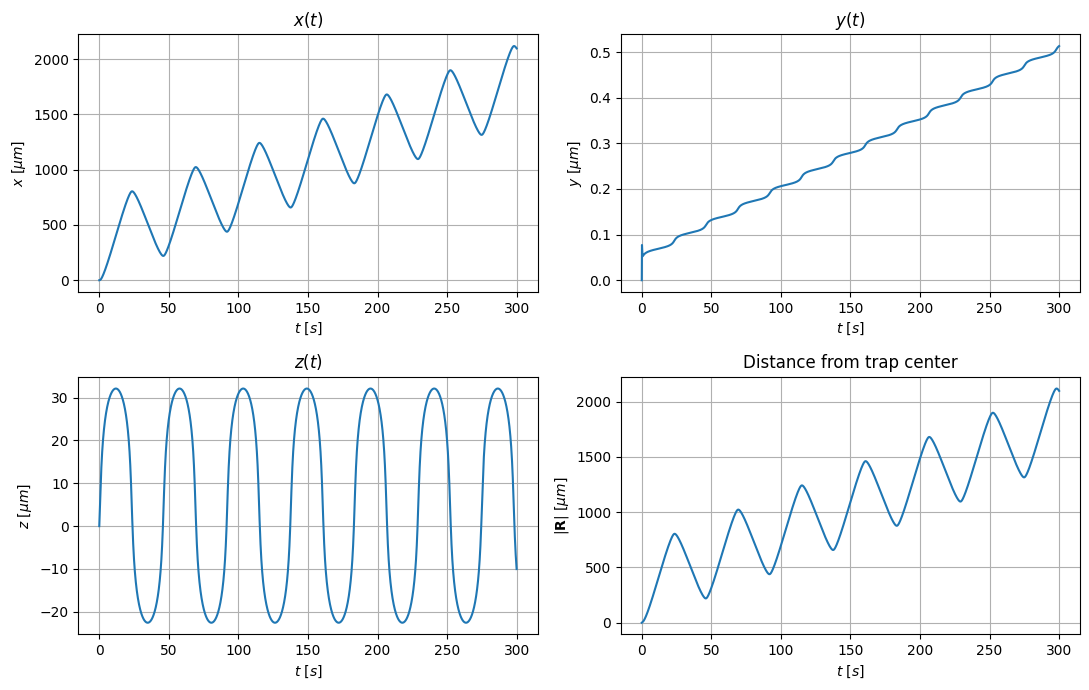

In [42]:
# ============================================================
# CENTER-OF-MASS POSITION
# ============================================================

fig, axs = plt.subplots(
    2, 2,
    figsize=(11, 7)
)

axs[0, 0].plot(sol_active.t, x_um)
axs[0, 0].set_title(r"$x(t)$")
axs[0, 0].set_xlabel(r"$t\ [s]$")
axs[0, 0].set_ylabel(r"$x\ [\mu m]$")
axs[0, 0].grid(True)

axs[0, 1].plot(sol_active.t, y_um)
axs[0, 1].set_title(r"$y(t)$")
axs[0, 1].set_xlabel(r"$t\ [s]$")
axs[0, 1].set_ylabel(r"$y\ [\mu m]$")
axs[0, 1].grid(True)

axs[1, 0].plot(sol_active.t, z_um)
axs[1, 0].set_title(r"$z(t)$")
axs[1, 0].set_xlabel(r"$t\ [s]$")
axs[1, 0].set_ylabel(r"$z\ [\mu m]$")
axs[1, 0].grid(True)

axs[1, 1].plot(
    sol_active.t,
    distance_um
)

axs[1, 1].set_title(
    "Distance from trap center"
)
axs[1, 1].set_xlabel(r"$t\ [s]$")
axs[1, 1].set_ylabel(r"$|\mathbf{R}|\ [\mu m]$")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

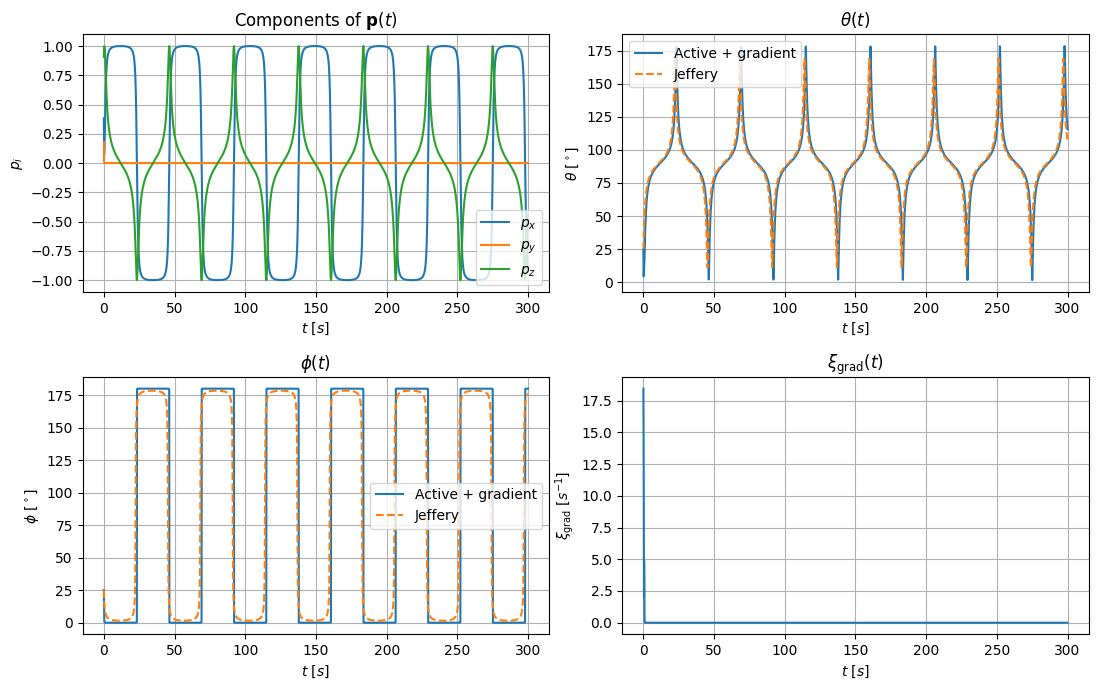

In [43]:
# ============================================================
# ORIENTATION
# ============================================================

fig, axs = plt.subplots(
    2, 2,
    figsize=(11, 7)
)

axs[0, 0].plot(
    sol_active.t,
    px_active,
    label=r"$p_x$"
)

axs[0, 0].plot(
    sol_active.t,
    py_active,
    label=r"$p_y$"
)

axs[0, 0].plot(
    sol_active.t,
    pz_active,
    label=r"$p_z$"
)

axs[0, 0].set_title(
    r"Components of $\mathbf{p}(t)$"
)
axs[0, 0].set_xlabel(r"$t\ [s]$")
axs[0, 0].set_ylabel(r"$p_i$")
axs[0, 0].legend()
axs[0, 0].grid(True)


axs[0, 1].plot(
    sol_active.t,
    theta_active_deg,
    label="Active + gradient"
)

axs[0, 1].plot(
    sol_jeffery.t,
    theta_deg,
    "--",
    label="Jeffery"
)

axs[0, 1].set_title(r"$\theta(t)$")
axs[0, 1].set_xlabel(r"$t\ [s]$")
axs[0, 1].set_ylabel(r"$\theta\ [^\circ]$")
axs[0, 1].legend()
axs[0, 1].grid(True)


axs[1, 0].plot(
    sol_active.t,
    phi_active_deg,
    label="Active + gradient"
)

axs[1, 0].plot(
    sol_jeffery.t,
    phi_deg,
    "--",
    label="Jeffery"
)

axs[1, 0].set_title(r"$\phi(t)$")
axs[1, 0].set_xlabel(r"$t\ [s]$")
axs[1, 0].set_ylabel(r"$\phi\ [^\circ]$")
axs[1, 0].legend()
axs[1, 0].grid(True)


axs[1, 1].plot(
    sol_active.t,
    xi_grad_history
)

axs[1, 1].set_title(
    r"$\xi_{\mathrm{grad}}(t)$"
)
axs[1, 1].set_xlabel(r"$t\ [s]$")
axs[1, 1].set_ylabel(r"$\xi_{\mathrm{grad}}\ [s^{-1}]$")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [44]:
import pyvista as pv

pv.set_jupyter_backend("server")

# ============================================================
# 3D ORIENTATION DYNAMICS
# Active particle + Jeffery + intensity-gradient torque
# ============================================================

plotter = pv.Plotter(
    window_size=(1100, 800)
)

plotter.set_background("white")


# ============================================================
# UNIT SPHERE S^2
# ============================================================

sphere = pv.Sphere(
    radius=1.0,
    theta_resolution=80,
    phi_resolution=80
)

plotter.add_mesh(
    sphere,
    color="lightgray",
    opacity=0.22,
    smooth_shading=True,
    specular=0.15,
    show_edges=False
)


# ============================================================
# INITIAL AND FINAL ORIENTATION
# ============================================================

p_initial = jf.normalize_vector(
    P_active[0]
)

p_final = jf.normalize_vector(
    P_active[-1]
)


# ------------------------------------------------------------
# Initial orientation
# ------------------------------------------------------------

p0_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=p_initial,
    tip_length=0.22,
    tip_radius=0.05,
    shaft_radius=0.018,
    scale=0.98
)

plotter.add_mesh(
    p0_arrow,
    color="green"
)

p0_point = pv.PolyData(
    p_initial.reshape(1, 3)
)

plotter.add_mesh(
    p0_point,
    color="green",
    point_size=9,
    render_points_as_spheres=True
)


# ------------------------------------------------------------
# Final orientation
# ------------------------------------------------------------

pf_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=p_final,
    tip_length=0.22,
    tip_radius=0.05,
    shaft_radius=0.018,
    scale=0.98
)

plotter.add_mesh(
    pf_arrow,
    color="blue"
)

pf_point = pv.PolyData(
    p_final.reshape(1, 3)
)

plotter.add_mesh(
    pf_point,
    color="blue",
    point_size=9,
    render_points_as_spheres=True
)


# ============================================================
# ACTIVE + INTENSITY-GRADIENT TRAJECTORY
# ============================================================

active_trajectory = pv.Spline(
    P_active,
    P_active.shape[0]
)

plotter.add_mesh(
    active_trajectory,
    color="red",
    line_width=4
)


# ============================================================
# PURE JEFFERY REFERENCE ORBIT
# ============================================================

jeffery_trajectory = pv.Spline(
    P,
    P.shape[0]
)

plotter.add_mesh(
    jeffery_trajectory,
    color="orange",
    line_width=2,
    opacity=0.75
)


# ============================================================
# INTENSITY-GRADIENT PREFERRED AXIS
# ============================================================

beam_axis_unit = (
    beam_axis /
    np.linalg.norm(beam_axis)
)

beam_axis_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=beam_axis_unit,
    tip_length=0.18,
    tip_radius=0.04,
    shaft_radius=0.012,
    scale=1.05
)

plotter.add_mesh(
    beam_axis_arrow,
    color="purple"
)


# Also show the opposite direction of the uniaxial axis

minus_beam_axis_arrow = pv.Arrow(
    start=(0.0, 0.0, 0.0),
    direction=-beam_axis_unit,
    tip_length=0.18,
    tip_radius=0.04,
    shaft_radius=0.012,
    scale=1.05
)

plotter.add_mesh(
    minus_beam_axis_arrow,
    color="purple"
)


# ============================================================
# BACKGROUND VELOCITY FIELD
# ============================================================

grid = np.linspace(
    -1.0,
    1.0,
    11
)

points = []
vectors = []

for a_grid in grid:
    for b_grid in grid:

        if plane == "xy":

            X = np.array([
                a_grid,
                b_grid,
                0.0
            ])

        elif plane == "xz":

            X = np.array([
                a_grid,
                0.0,
                b_grid
            ])

        elif plane == "yz":

            X = np.array([
                0.0,
                a_grid,
                b_grid
            ])

        else:

            raise ValueError(
                "plane must be 'xy', 'xz' or 'yz'"
            )

        u = G @ X

        points.append(X)
        vectors.append(u)


points = np.asarray(points)
vectors = np.asarray(vectors)

flow_mesh = pv.PolyData(
    points
)

flow_mesh["velocity"] = vectors

flow_glyphs = flow_mesh.glyph(
    orient="velocity",
    scale="velocity",
    factor=0.30
)

plotter.add_mesh(
    flow_glyphs,
    color="black",
    opacity=0.65
)


# ============================================================
# AXES AND BOUNDS
# ============================================================

plotter.add_axes(
    line_width=3,
    xlabel="px",
    ylabel="py",
    zlabel="pz"
)

plotter.show_bounds(
    grid="front",
    location="outer",
    all_edges=True,
    color="black",
    xtitle="px",
    ytitle="py",
    ztitle="pz",
    font_size=18
)


# ============================================================
# TEXT
# ============================================================

if plane == "xy":

    flow_text = (
        f"u = ({gamma:g} y, 0, 0)"
    )

elif plane == "xz":

    flow_text = (
        f"u = ({gamma:g} z, 0, 0)"
    )

elif plane == "yz":

    flow_text = (
        "simple shear in yz"
    )


plotter.add_text(
    "Active particle + intensity-gradient torque\n"
    f"{flow_text}\n"
    f"aspect ratio = {aspect_ratio:.3f}, beta = {beta:.3f}\n"
    f"v_s = {swimming_speed:.2e} m/s",
    position="upper_left",
    font_size=15,
    color="black"
)


# ============================================================
# LEGEND
# ============================================================

plotter.add_legend(
    labels=[
        ["initial orientation", "green"],
        ["final orientation", "blue"],
        ["active + gradient torque", "red"],
        ["pure Jeffery", "orange"],
        ["gradient preferred axis", "purple"],
        ["background flow", "black"]
    ],
    bcolor="white",
    border=False,
    face="circle",
    size=(0.25, 0.22)
)


# ============================================================
# CAMERA
# ============================================================

plotter.camera_position = "iso"
plotter.camera.zoom(1.15)

plotter.show()

Widget(value='<iframe src="http://localhost:59494/index.html?ui=P_0x144c31cd0_1&reconnect=auto" class="pyvista…

In [45]:
print("R0 [um] =", 1e6 * R_active[0])
print("Rf [um] =", 1e6 * R_active[-1])

print(
    "maximum distance from initial position [um] =",
    1e6 * np.max(
        np.linalg.norm(
            R_active - R_active[0],
            axis=1
        )
    )
)

print(
    "maximum distance from focus [um] =",
    1e6 * np.max(
        np.linalg.norm(
            R_active,
            axis=1
        )
    )
)

print("w0 [um] =", 1e6 * w0)

print(
    "xi_grad initial =",
    xi_grad_history[0],
    "1/s"
)

print(
    "xi_grad min =",
    np.min(xi_grad_history),
    "1/s"
)

print(
    "xi_grad max =",
    np.max(xi_grad_history),
    "1/s"
)

R0 [um] = [0. 0. 0.]
Rf [um] = [ 2.09618816e+03  5.13228545e-01 -1.00212997e+01]
maximum distance from initial position [um] = 2117.450573780377
maximum distance from focus [um] = 2117.450573780377
w0 [um] = 1.9
xi_grad initial = 18.436430408147697 1/s
xi_grad min = 0.0 1/s
xi_grad max = 18.436430408147697 1/s
